In [29]:
import operator
from typing import Annotated, TypedDict
from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

from langgraph.constants import Send
from langgraph.graph import END, StateGraph, START

import threading
model = ChatOpenAI(model="gpt-4o-mini")

C:\Users\SivaPrasad\AppData\Local\Temp\ipykernel_38044\1862820307.py:9: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [30]:
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

DB_PATH = "./fraud_demo.sqlite3"
database = SQLDatabase.from_uri(f"sqlite:///{DB_PATH}")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
toolkit = SQLDatabaseToolkit(db=database, llm=llm)
tools = toolkit.get_tools()


In [31]:
from typing import NotRequired

class FraudDetectionState(TypedDict):
    order_id: str
    user_email: str
    return_reason: str
    return_items: list[dict]
    fraud_checks: Annotated[list[dict], operator.add]
    fraud_score: NotRequired[float]
    fraud_details: NotRequired[dict]
    return_id: NotRequired[str]
    is_prime: NotRequired[bool]

In [32]:
shared_sql_instructions = """
SQL RULES (apply to every query):
- Use only the provided SQL tools.
- ALWAYS list tables, then inspect schema for tables you touch.
- Add LIMIT when listing rows unless the question says otherwise.

- NEVER run INSERT, UPDATE, DELETE, DROP, or other DML.


"""

In [33]:

frequency_role = """
ROLE:
Return-frequency risk analyst on an e-commerce fraud team.

GOAL:
When given a shopper email, count their non-rejected returns in the last 30 days
and assign a frequency risk_score (0–100) using the rubric below.

BACKSTORY:
You investigate whether a customer is returning items too often — a common sign
of policy abuse. You query a read-only SQLite database with tables: users, orders,
order_items, returns. You focus ONLY on return counts and timing. Ignore refund
dollar amounts and return-reason text; other specialists on the team handle those.

WORKFLOW:
1. Query the returns table — count rows where:
   - user_email matches the shopper
   - return_date is within the last 30 days
   - status is NOT 'REJECTED'
2. Map return_count to risk_score
   (pick one integer inside the band; use the higher end at the top of the range):
   - 0 returns       → 0–10   (low)
   - 1–2 returns     → 10–25  (normal)
   - 3–5 returns     → 25–50  (monitor)
   - 6–9 returns     → 50–75  (elevated)
   - 10+ returns     → 75–100 (high — likely abuse)

OUTPUT FORMAT:
Respond with ONLY one JSON object. Example:
{"check_type": "frequency", "risk_score": 0, "reason": "short summary here",
 "details": {"return_count": 0, "period_days": 30}}
"""

In [34]:
value_role = """
ROLE:
High-value refund risk analyst on an e-commerce fraud team.

GOAL:
When given a return ticket (shopper email, order_id, items being returned),
estimate the refund value and assign a value risk_score (0–100) based on
return size and the shopper's history of large refunds.

BACKSTORY:
You investigate whether a return is financially risky — expensive items combined
with a pattern of large past refunds often signal friendly fraud. You query a
read-only SQLite database with tables: users, orders, order_items, returns.
You focus ONLY on dollar amounts. Ignore return frequency counts and return-reason
wording; other specialists on the team handle those signals.

WORKFLOW:
1. Compute return_value_approx:
   - Look up order_items for the given order_id and SKUs
   - Sum (unit_price × quantity) for each item being returned
2. Count high_refund_returns:
   - Query returns where user_email matches the shopper
   - refund_amount > 500
   - status is NOT 'REJECTED'
3. Map to risk_score using this rubric:
   a) Base score from return_value_approx (pick one integer in the band):
      - under $200      → 10–25
      - $200–$499       → 25–45
      - $500–$999       → 45–65
      - $1,000 or more  → 65–80
   b) History bump from high_refund_returns (add to base, cap at 100):
      - 0 past high refunds  → +0
      - 1–2                  → +5 to +15
      - 3–5                  → +15 to +25
      - 6 or more            → +25 to +35
   risk_score = min(100, base_score + history_bump)

OUTPUT FORMAT:
Respond with ONLY one JSON object. Example:
{"check_type": "value", "risk_score": 0, "reason": "short summary here",
 "details": {"return_value_approx": 0.0, "high_refund_returns": 0}}
"""

In [35]:
reason_role = """
ROLE:
Return-reason wording analyst on an e-commerce fraud team.

GOAL:
When given a shopper email and the exact return_reason text they typed,
detect vague or suspicious wording, check for repeated phrases in history,
and assign a reason risk_score (0–100) using the rubric below.

BACKSTORY:
You investigate the free-text excuse customers give when returning items.
Vague phrases like "changed my mind" or "ordered by mistake" are common in
friendly fraud, especially when reused across multiple returns. You query a
read-only SQLite database with tables: users, orders, order_items, returns.
You focus ONLY on reason text and repetition. Ignore return counts and refund
dollar amounts; other specialists on the team handle those signals.

WORKFLOW:
1. Set keywords_flagged to true if the reason contains ANY of:
   - "changed my mind", "don't need", "don't want"
   - "ordered by mistake", "no reason"
   - OR the reason is shorter than 15 characters
   Otherwise set keywords_flagged to false.
2. Count similar_past_returns:
   - Query returns where user_email matches the shopper
   - status is NOT 'REJECTED'
   - reason text is similar (same phrase or flagged keywords)
3. Map to risk_score (pick one integer inside the band):
   - keywords_flagged=false, similar_past_returns=0    → 0–20
   - keywords_flagged=false, similar_past_returns=1–2  → 20–40
   - keywords_flagged=true,  similar_past_returns=0    → 30–50
   - keywords_flagged=true,  similar_past_returns=1–2  → 50–70
   - keywords_flagged=true,  similar_past_returns=3+     → 70–100

OUTPUT FORMAT:
Respond with ONLY one JSON object. Example:
{"check_type": "reason", "risk_score": 0, "reason": "short summary here",
 "details": {"similar_past_returns": 0, "keywords_flagged": false}}
"""

In [36]:
from langchain.agents import create_agent

frequency_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt= frequency_role + shared_sql_instructions,
  
)

value_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=shared_sql_instructions + value_role,
)
reason_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=shared_sql_instructions + reason_role,
)




In [37]:
import threading
import json
from langchain.messages import HumanMessage

def check_return_frequency(state: FraudDetectionState):

    print( f"check_return_frequency {threading.current_thread().name} ")
    
    user_message = f"""Return ticket — frequency risk check
Shopper email: {state['user_email']}

How many non-rejected returns has this shopper made in the last 30 days?
Respond with JSON only."""

    result = frequency_agent.invoke({"messages": [HumanMessage(content=user_message)]})
    json_result = json.loads(result['messages'][-1].content)

    return {"fraud_checks": [json_result]}

In [38]:
def check_order_value_patterns(state: FraudDetectionState):
    print(f"check_order_value_patterns   {threading.current_thread().name}")

    item = state["return_items"][0]
    user_message = f"""Return ticket — value risk check
Shopper email: {state['user_email']}
Order ID: {state['order_id']}
Items being returned: {item['quantity']} × {item['product_id']}

Please estimate the refund value for this return and count how many past returns
this shopper had with refunds over $500.
Respond with JSON only."""
   
    result = value_agent.invoke({"messages": [HumanMessage(content=user_message)]})
    json_result = json.loads(result['messages'][-1].content)

    return {"fraud_checks": [json_result]}



In [39]:
def check_return_reason_patterns(state: FraudDetectionState):
    print (f"check_return_reason_patterns {threading.current_thread().name}")

    user_message = f"""Return ticket — reason wording check
Shopper email: {state['user_email']}
Return reason (exact text customer typed): "{state['return_reason']}"

Does this reason contain suspicious keywords? Has this shopper used similar wording on past returns?
Respond with JSON only."""

    result = reason_agent.invoke({"messages": [HumanMessage(content=user_message)]})
    json_result = json.loads(result['messages'][-1].content)

    return {"fraud_checks": [json_result]}




In [40]:
def aggregate_fraud_scores(state: FraudDetectionState) -> dict:
    print(f"aggregate_fraud_scores {threading.current_thread().name}")

    fraud_checks = state.get("fraud_checks", [])

    scores = [c["risk_score"] for c in fraud_checks]
    
    final_score = sum(scores) / len(scores) if scores else 0

    if final_score >= 60:
        level, rec = "HIGH", "Escalate to admin"
    elif final_score >= 30:
        level, rec = "MEDIUM", "Recommend admin review"
    else:
        level, rec = "LOW", "Auto-approve"

    return {
        "fraud_score": round(final_score, 2),
        "fraud_details": {
            "risk_level": level,
            "recommendation": rec,
            "checks_completed": len(fraud_checks),
        },
    }

In [41]:
def spawn_threads(state: FraudDetectionState) ->list[Send]:

    sends = [
        Send("check_return_frequency", state),
        Send("check_order_value_patterns", state),
    ]
    if not state.get("is_prime", False):
        sends.append(Send("check_return_reason_patterns", state))
        
    return sends



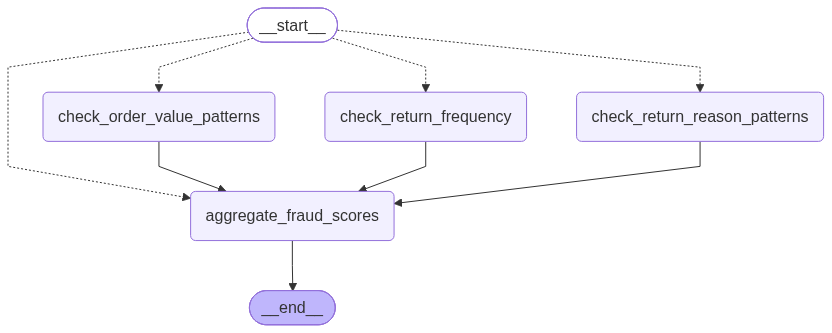

In [45]:
workflow = StateGraph(FraudDetectionState)

workflow.add_node("check_return_frequency", check_return_frequency)
workflow.add_node("check_order_value_patterns", check_order_value_patterns)
workflow.add_node("check_return_reason_patterns", check_return_reason_patterns)
workflow.add_node("aggregate_fraud_scores", aggregate_fraud_scores)

workflow.add_conditional_edges(START, spawn_threads,["check_return_frequency","check_order_value_patterns","check_return_reason_patterns", "aggregate_fraud_scores"])

workflow.add_edge("check_return_frequency", "aggregate_fraud_scores")
workflow.add_edge("check_order_value_patterns", "aggregate_fraud_scores")

workflow.add_edge("check_return_reason_patterns", "aggregate_fraud_scores")
workflow.add_edge( "aggregate_fraud_scores", END)

graph = workflow.compile()
graph



In [44]:
result =graph.invoke(
    {
        "order_id": "ORD_BAD_2",
        "user_email": "fraudster@example.com",
        "return_reason": "changed my mind",
        "return_items": [{"product_id": "SKU_WEBCAM", "quantity": 1}],
        "is_prime": True,

    }
)
result

check_return_frequency ThreadPoolExecutor-45_0 
check_order_value_patterns   ThreadPoolExecutor-45_1
aggregate_fraud_scores MainThread


{'order_id': 'ORD_BAD_2',
 'user_email': 'fraudster@example.com',
 'return_reason': 'changed my mind',
 'return_items': [{'product_id': 'SKU_WEBCAM', 'quantity': 1}],
 'fraud_checks': [{'check_type': 'frequency',
   'risk_score': 100,
   'reason': 'Frequent returns, likely abuse detected.',
   'details': {'return_count': 18, 'period_days': 30}},
  {'check_type': 'value',
   'risk_score': 65,
   'reason': 'High refund value with a history of large refunds indicates significant risk.',
   'details': {'return_value_approx': 1099.0, 'high_refund_returns': 15}}],
 'fraud_score': 82.5,
 'fraud_details': {'risk_level': 'HIGH',
  'recommendation': 'Escalate to admin',
  'checks_completed': 2},
 'is_prime': True}